# Week 1 Case Study: Deep Learning Fundamentals


In [2]:
# ---- Part 0: Environment Setup ----
# You may uncomment installs in Colab if needed.
# !pip install -q numpy pandas matplotlib seaborn scikit-learn tensorflow

import os, sys, random, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    tf.random.set_seed(SEED)
except Exception as e:
    print("TensorFlow not imported yet (this is OK until Part 3):", e)

pd.set_option('display.max_columns', 100)


### Dataset

**Heart Disease Prediction Dataset** (see instructions). Provide your own local/Drive copy.  
Set `DATA_PATH` below to the CSV. Avoid hardcoding private paths.


In [3]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()  # Choose your CSV file
filename = next(iter(uploaded))

df = pd.read_csv(io.BytesIO(uploaded[filename]))
df.head()  # Display the first 5 rows

Saving dataset_heart.csv to dataset_heart.csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Part 1: Data Preparation & Analysis (10 pts)

### Tasks
1. Load the heart disease dataset; preview shape, dtypes, head/tail.  
2. Compute basic stats per column and check missing values.  
3. Visualize target balance and select 2–3 key feature distributions.  
4. Handle missing values and simple outlier checks; document decisions.  
5. Create **train/val/test** split with no leakage.


In [4]:
# data preview shape, dtypes, head/tail info

print("Shape:", df.shape)
display(df.dtypes.rename("dtype"))
display(df.head())
display(df.tail())



Shape: (1025, 14)


,dtype
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [5]:
# Basic stats & check for missing values
display(df.describe(include='all'))
df.isna().sum()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


## There are no missing values

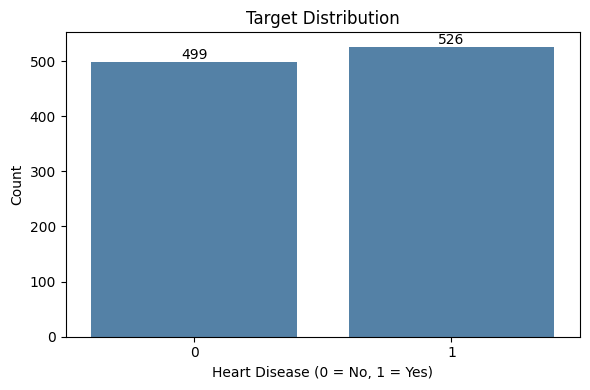

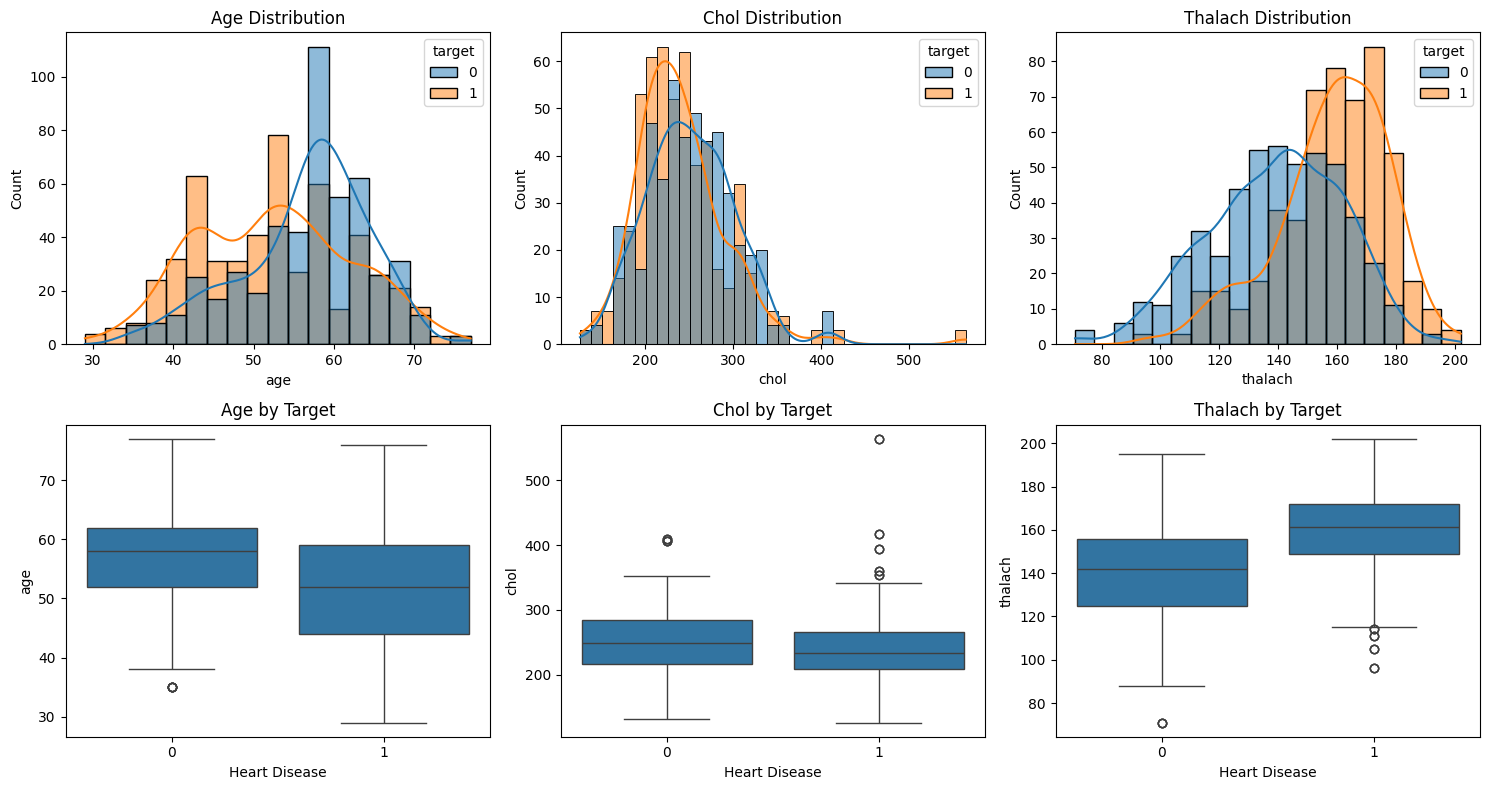

In [6]:
# Visualize target balance and select 2–3 key feature distributions.
TARGET_COL = "target"
FEATURES = ["age", "chol", "thalach"]

# Target balance
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x=TARGET_COL, color="steelblue")
ax.set(title="Target Distribution", xlabel="Heart Disease (0 = No, 1 = Yes)", ylabel="Count")
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

# Feature distributions and outlier checks
fig, axes = plt.subplots(2, len(FEATURES), figsize=(15, 8))

for index, feature in enumerate(FEATURES):
    sns.histplot(
        data=df,
        x=feature,
        hue=TARGET_COL,
        kde=True,
        multiple="layer",
        ax=axes[0, index],
    )
    axes[0, index].set_title(f"{feature.title()} Distribution")

    sns.boxplot(data=df, x=TARGET_COL, y=feature, ax=axes[1, index])
    axes[1, index].set_title(f"{feature.title()} by Target")
    axes[1, index].set_xlabel("Heart Disease")

plt.tight_layout()
plt.show()

In [7]:
# Missing-value check and outlier checks.
missing_counts = df.isna().sum()
display(missing_counts.rename("missing_count"))

if missing_counts.sum() == 0:
    print("No missing values found; no imputation or row removal required.")
else:
    print("Missing values detected. Imputation should be fitted on training data only.")

# IQR outlier check for continuous clinical features
continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

q1 = df[continuous_cols].quantile(0.25)
q3 = df[continuous_cols].quantile(0.75)
iqr = q3 - q1

lower_bounds = q1 - 1.5 * iqr
upper_bounds = q3 + 1.5 * iqr

outlier_mask = (
    (df[continuous_cols] < lower_bounds)
    | (df[continuous_cols] > upper_bounds)
)

outlier_summary = pd.DataFrame({
    "lower_bound": lower_bounds,
    "upper_bound": upper_bounds,
    "outlier_count": outlier_mask.sum(),
    "outlier_percent": outlier_mask.mean().mul(100).round(2),
})

display(outlier_summary)
print(
    "Potential outliers were retained because they may represent valid clinical "
    "measurements. IQR flags unusual values but does not prove they are errors."
)

,missing_count
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


No missing values found; no imputation or row removal required.


,lower_bound,upper_bound,outlier_count,outlier_percent
age,28.5,80.5,0,0.00
trestbps,90.0,170.0,30,2.93
chol,115.0,371.0,16,1.56
thalach,81.0,217.0,4,0.39
oldpeak,-2.7,4.5,7,0.68


Potential outliers were retained because they may represent valid clinical measurements. IQR flags unusual values but does not prove they are errors.


In [8]:
#Create train/validation/test data with no leakage

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Reserve 20% for testing
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

# 25% of the remaining 80% gives 20% of the full dataset
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp,
    y_tmp,
    test_size=0.25,
    random_state=SEED,
    stratify=y_tmp,
)

# Fit preprocessing only on training data to prevent leakage
scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns,
    index=X_train.index,
)
X_val = pd.DataFrame(
    scaler.transform(X_val),
    columns=X.columns,
    index=X_val.index,
)
X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns,
    index=X_test.index,
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print("\nTarget proportions:")
print("Train:", y_train.mean().round(3))
print("Validation:", y_val.mean().round(3))
print("Test:", y_test.mean().round(3))

Train: (615, 13)
Validation: (205, 13)
Test: (205, 13)

Target proportions:
Train: 0.514
Validation: 0.512
Test: 0.512


### We have splitted 20% data for test, 20% for validation and 60% for training the model. We have applied standard scalar only on the training data to avoid the data leakage

# Part 2: Neural Network from Scratch (NumPy) (15 pts)

### Tasks
1. Prepare NumPy arrays with correct shapes.  
2. Implement forward pass (linear → sigmoid).  
3. Implement binary cross-entropy loss and backprop.  
4. Update weights with gradient descent.  
5. Track loss/accuracy; evaluate on val/test.


In [9]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid_derivative(a):
    return a * (1.0 - a)


class TinyMLP:
    def __init__(self, input_dim, hidden_dim, output_dim, seed=SEED):
        rng = np.random.default_rng(seed)

        self.W1 = rng.normal(
            0, np.sqrt(1 / input_dim), size=(input_dim, hidden_dim)
        )
        self.b1 = np.zeros((1, hidden_dim))

        self.W2 = rng.normal(
            0, np.sqrt(1 / hidden_dim), size=(hidden_dim, output_dim)
        )
        self.b2 = np.zeros((1, output_dim))

    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = sigmoid(z1)

        z2 = a1 @ self.W2 + self.b2
        a2 = sigmoid(z2)

        return a1, a2

    def compute_loss(self, y_true, y_pred):
        epsilon = 1e-12
        y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon)

        return -np.mean(
            y_true * np.log(y_pred)
            + (1.0 - y_true) * np.log(1.0 - y_pred)
        )

    def backward(self, X, y_true, a1, a2, lr=0.1):
        sample_count = X.shape[0]

        # BCE combined with sigmoid gives a2 - y_true
        dz2 = a2 - y_true
        dW2 = (a1.T @ dz2) / sample_count
        db2 = np.sum(dz2, axis=0, keepdims=True) / sample_count

        da1 = dz2 @ self.W2.T
        dz1 = da1 * sigmoid_derivative(a1)
        dW1 = (X.T @ dz1) / sample_count
        db1 = np.sum(dz1, axis=0, keepdims=True) / sample_count

        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        self.W2 -= lr * dW2
        self.b2 -= lr * db2


# Prepare arrays
Xtr = X_train.to_numpy(dtype=np.float64)
Xv = X_val.to_numpy(dtype=np.float64)

ytr = y_train.to_numpy(dtype=np.float64).reshape(-1, 1)
yv = y_val.to_numpy(dtype=np.float64).reshape(-1, 1)

# Train model
EPOCHS = 1000
LR = 0.1
HIDDEN_UNITS = 8

model = TinyMLP(
    input_dim=Xtr.shape[1],
    hidden_dim=HIDDEN_UNITS,
    output_dim=1,
)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
}

for epoch in range(EPOCHS + 1):
    a1, train_prob = model.forward(Xtr)
    model.backward(Xtr, ytr, a1, train_prob, lr=LR)

    _, train_prob = model.forward(Xtr)
    _, val_prob = model.forward(Xv)

    train_loss = model.compute_loss(ytr, train_prob)
    val_loss = model.compute_loss(yv, val_prob)

    train_accuracy = np.mean((train_prob >= 0.5) == ytr)
    val_accuracy = np.mean((val_prob >= 0.5) == yv)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)

    if epoch % 100 == 0:
        print(
            f"epoch {epoch:4d} | "
            f"loss={train_loss:.4f} | "
            f"accuracy={train_accuracy:.3f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_accuracy={val_accuracy:.3f}"
        )

epoch    0 | loss=0.7050 | accuracy=0.486 | val_loss=0.7125 | val_accuracy=0.488
epoch  100 | loss=0.5116 | accuracy=0.815 | val_loss=0.5164 | val_accuracy=0.834
epoch  200 | loss=0.4057 | accuracy=0.844 | val_loss=0.4246 | val_accuracy=0.849
epoch  300 | loss=0.3663 | accuracy=0.849 | val_loss=0.4030 | val_accuracy=0.854
epoch  400 | loss=0.3495 | accuracy=0.857 | val_loss=0.4011 | val_accuracy=0.863
epoch  500 | loss=0.3410 | accuracy=0.857 | val_loss=0.4043 | val_accuracy=0.863
epoch  600 | loss=0.3358 | accuracy=0.859 | val_loss=0.4083 | val_accuracy=0.863
epoch  700 | loss=0.3322 | accuracy=0.854 | val_loss=0.4120 | val_accuracy=0.849
epoch  800 | loss=0.3292 | accuracy=0.852 | val_loss=0.4149 | val_accuracy=0.849
epoch  900 | loss=0.3263 | accuracy=0.854 | val_loss=0.4170 | val_accuracy=0.839
epoch 1000 | loss=0.3234 | accuracy=0.854 | val_loss=0.4183 | val_accuracy=0.839


### Unlike KERA block - this numpy training loop does not stop early if validation performance degrades.

,accuracy,precision,recall,f1,roc_auc
Validation,0.8390,0.8462,0.8381,0.8421,0.8971
Test,0.8293,0.8070,0.8762,0.8402,0.9344


Test classification report:
              precision    recall  f1-score   support

         0.0     0.8571    0.7800    0.8168       100
         1.0     0.8070    0.8762    0.8402       105

    accuracy                         0.8293       205
   macro avg     0.8321    0.8281    0.8285       205
weighted avg     0.8315    0.8293    0.8288       205



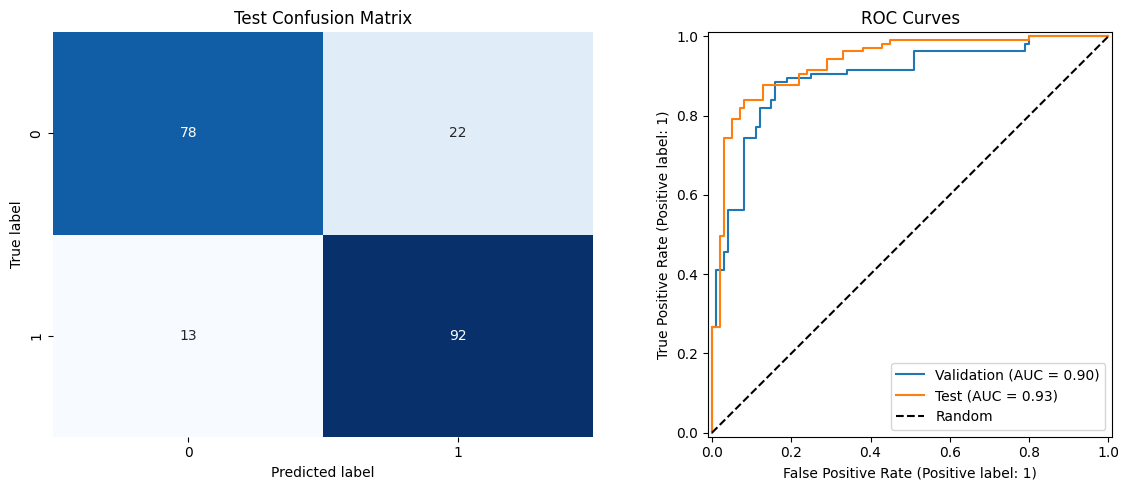

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
)

Xte = X_test.to_numpy(dtype=np.float64)
yte = y_test.to_numpy(dtype=np.float64).reshape(-1, 1)


def evaluate_model(model, X_values, y_true):
    _, probabilities = model.forward(X_values)
    probabilities = probabilities.ravel()
    y_true = y_true.ravel()
    predictions = (probabilities >= 0.5).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
    }

    return metrics, probabilities, predictions


val_metrics, val_prob, val_pred = evaluate_model(model, Xv, yv)
test_metrics, test_prob, test_pred = evaluate_model(model, Xte, yte)

results = pd.DataFrame(
    [val_metrics, test_metrics],
    index=["Validation", "Test"],
).round(4)

display(results)

print("Test classification report:")
print(classification_report(yte.ravel(), test_pred, digits=4))

# Confusion matrix and ROC curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    confusion_matrix(yte.ravel(), test_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[0],
)
axes[0].set_title("Test Confusion Matrix")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

RocCurveDisplay.from_predictions(
    yv.ravel(),
    val_prob,
    name="Validation",
    ax=axes[1],
)
RocCurveDisplay.from_predictions(
    yte.ravel(),
    test_prob,
    name="Test",
    ax=axes[1],
)
axes[1].plot([0, 1], [0, 1], "k--", label="Random")
axes[1].set_title("ROC Curves")
axes[1].legend()

plt.tight_layout()
plt.show()

### We get Test Accuracy of around 82.9 % using numpy model

# Part 3: TensorFlow/Keras Implementation (12 pts)

### Tasks
1. Build a small Sequential/Functional model mirroring Part 2.  
2. Choose correct loss/metrics for binary classification.  
3. Train for a few epochs; log history.  
4. Try a second configuration (activation/optimizer) and compare.  
5. Compare Keras vs. NumPy results briefly.


In [11]:
# ---- Keras baseline model ----
keras.utils.set_random_seed(SEED)

def build_keras_baseline(input_dim, hidden_units=8):
    return keras.Sequential(
        [
            layers.Input(shape=(input_dim,)),
            layers.Dense(hidden_units, activation="sigmoid"),
            layers.Dense(1, activation="sigmoid"),
        ],
        name="baseline_ffnn",
    )


keras_model = build_keras_baseline(
    input_dim=X_train.shape[1],
    hidden_units=HIDDEN_UNITS,
)

keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc"),
    ],
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

hist = keras_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1,
)

keras_model.summary()

test_loss, test_accuracy, test_auc = keras_model.evaluate(
    X_test,
    y_test,
    verbose=0,
)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test AUC:      {test_auc:.4f}")

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5138 - auc: 0.1483 - loss: 0.8859 - val_accuracy: 0.5122 - val_auc: 0.1709 - val_loss: 0.8680
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5138 - auc: 0.1752 - loss: 0.8456 - val_accuracy: 0.5122 - val_auc: 0.1990 - val_loss: 0.8278
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5138 - auc: 0.2169 - loss: 0.8097 - val_accuracy: 0.5122 - val_auc: 0.2567 - val_loss: 0.7917
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5138 - auc: 0.2752 - loss: 0.7776 - val_accuracy: 0.5122 - val_auc: 0.3384 - val_loss: 0.7594
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5138 - auc: 0.3603 - loss: 0.7490 - val_accuracy: 0.5122 - val_auc: 0.4599 - val_loss: 0.7307
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5138 - auc: 0.4741 - loss: 0.7235 - val_accuracy: 0.5122 - val_auc: 0.5897 - val_loss: 0.7050
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step -

Model: "baseline_ffnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365 (1.43 KB)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 244 (980.00 B)

Test loss:     0.3945
Test accuracy: 0.8439
Test AUC:      0.9219


### Here we get test accuracy of around 84.3 % which is better then numpy model

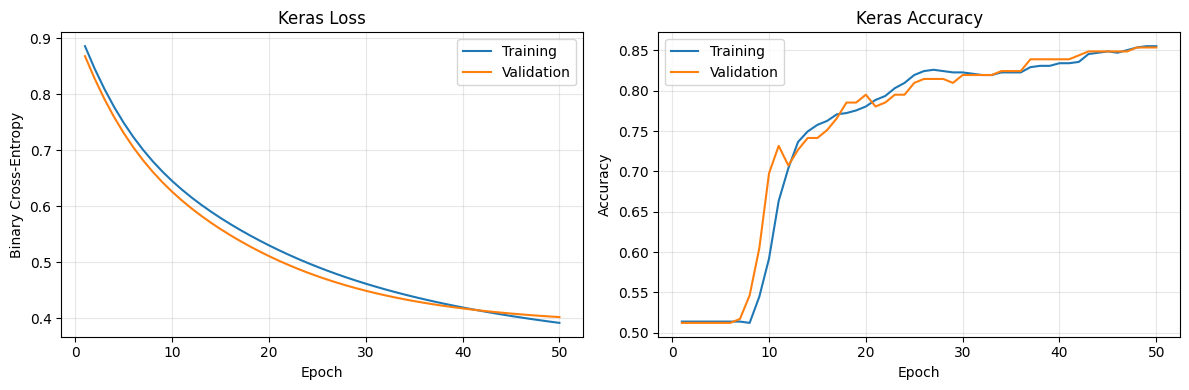

In [12]:
# Plot Keras training curves
epochs_ran = range(1, len(hist.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_ran, hist.history["loss"], label="Training")
axes[0].plot(epochs_ran, hist.history["val_loss"], label="Validation")
axes[0].set(
    title="Keras Loss",
    xlabel="Epoch",
    ylabel="Binary Cross-Entropy",
)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, hist.history["accuracy"], label="Training")
axes[1].plot(epochs_ran, hist.history["val_accuracy"], label="Validation")
axes[1].set(
    title="Keras Accuracy",
    xlabel="Epoch",
    ylabel="Accuracy",
)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### KERA model has better results then numpy based model

# Part 4: Hyperparameter Analysis (5 pts)

### Tasks
1. Define a **small** search space (e.g., 2 learning rates × 2 hidden sizes).  
2. Train briefly for each config.  
3. Collect val metrics in a list → DataFrame.  
4. Plot a simple comparison (bar/line).  
5. Write 4–6 sentences on what changed and why.


,optimizer,learning_rate,hidden_units,epochs,val_loss,val_accuracy,val_auc,configuration
0,adam,0.001,16,36,0.3910,0.8634,0.9041,"h=16, lr=0.001"
1,adam,0.010,8,12,0.3921,0.8585,0.9030,"h=8, lr=0.01"
2,adam,0.010,16,8,0.3908,0.8585,0.9050,"h=16, lr=0.01"
3,adam,0.001,8,40,0.4175,0.8390,0.9051,"h=8, lr=0.001"
4,sgd,0.010,16,40,0.4663,0.8195,0.8975,"h=16, lr=0.01"
5,sgd,0.010,8,40,0.6123,0.7512,0.8186,"h=8, lr=0.01"
6,sgd,0.001,16,40,0.6172,0.7024,0.8011,"h=16, lr=0.001"
7,sgd,0.001,8,40,0.8031,0.4780,0.1821,"h=8, lr=0.001"


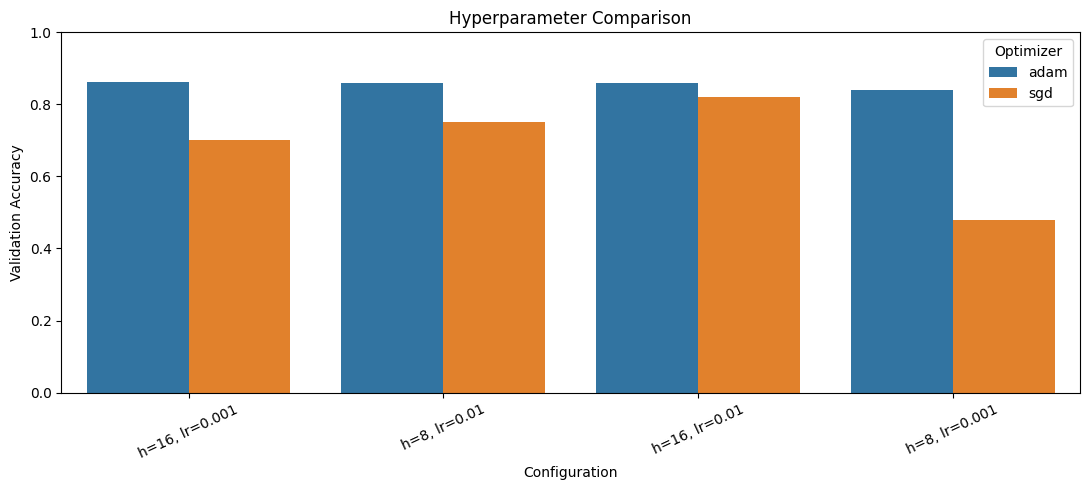

The sweep compared 8 configurations. The best used ADAM with a learning rate of 0.001 and 16 hidden units. It achieved validation accuracy of 0.863 and AUC of 0.904. Learning rate affects update size, while hidden-unit count controls model capacity. The test set was not used during selection, which avoids leakage.


In [13]:
# ---- Mini hyperparameter sweep ----
results = []

search_space = {
    "lr": [0.01, 0.001],
    "hidden": [8, 16],
    "optimizer": ["adam", "sgd"],
}

for optimizer_name in search_space["optimizer"]:
    for learning_rate in search_space["lr"]:
        for hidden_units in search_space["hidden"]:
            keras.backend.clear_session()
            keras.utils.set_random_seed(SEED)

            sweep_model = build_keras_baseline(
                input_dim=X_train.shape[1],
                hidden_units=hidden_units,
            )

            if optimizer_name == "adam":
                optimizer = keras.optimizers.Adam(
                    learning_rate=learning_rate
                )
            else:
                optimizer = keras.optimizers.SGD(
                    learning_rate=learning_rate
                )

            sweep_model.compile(
                optimizer=optimizer,
                loss="binary_crossentropy",
                metrics=[
                    keras.metrics.BinaryAccuracy(name="accuracy"),
                    keras.metrics.AUC(name="auc"),
                ],
            )

            sweep_history = sweep_model.fit(
                X_train,
                y_train,
                validation_data=(X_val, y_val),
                epochs=40,
                batch_size=32,
                callbacks=[
                    keras.callbacks.EarlyStopping(
                        monitor="val_loss",
                        patience=5,
                        restore_best_weights=True,
                    )
                ],
                verbose=0,
            )

            val_metrics = sweep_model.evaluate(
                X_val,
                y_val,
                verbose=0,
                return_dict=True,
            )

            results.append({
                "optimizer": optimizer_name,
                "learning_rate": learning_rate,
                "hidden_units": hidden_units,
                "epochs": len(sweep_history.history["loss"]),
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_auc": val_metrics["auc"],
            })

df_results = (
    pd.DataFrame(results)
    .sort_values("val_accuracy", ascending=False)
    .reset_index(drop=True)
)

df_results["configuration"] = (
    "h=" + df_results["hidden_units"].astype(str)
    + ", lr=" + df_results["learning_rate"].astype(str)
)

display(df_results.round(4))

# Compare validation accuracy
plt.figure(figsize=(11, 5))
ax = sns.barplot(
    data=df_results,
    x="configuration",
    y="val_accuracy",
    hue="optimizer",
)

ax.set(
    title="Hyperparameter Comparison",
    xlabel="Configuration",
    ylabel="Validation Accuracy",
    ylim=(0, 1),
)
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Optimizer")
plt.tight_layout()
plt.show()

# Summarize the best configuration
best = df_results.iloc[0]

print(
    f"The sweep compared {len(df_results)} configurations. "
    f"The best used {best['optimizer'].upper()} with a learning rate of "
    f"{best['learning_rate']} and {int(best['hidden_units'])} hidden units. "
    f"It achieved validation accuracy of {best['val_accuracy']:.3f} and "
    f"AUC of {best['val_auc']:.3f}. "
    "Learning rate affects update size, while hidden-unit count controls model "
    "capacity. The test set was not used during selection, which avoids leakage."
)

# Part 5: Written Analysis & Reflection (3 pts)

### Write-up Prompts (300–500 words)

1. Summarize your modeling approaches and findings (NumPy vs. Keras).  
2. Identify one bias/fairness/ethics concern in the dataset or pipeline.  
3. Explain how your preprocessing or modeling choices influence this concern.  
4. Propose one mitigation step and how to evaluate its effectiveness.  
5. Share your key insight about deep learning fundamentals from this case study.


**1. Summarize your modeling approaches and findings (NumPy vs. Keras).**
- The NumPy model and the Keras model both used a feed-forward neural network with one sigmoid hidden layer and a sigmoid output for binary classification. In NumPy, I implemented the forward pass, binary cross-entropy loss, backpropagation, and gradient-descent updates manually.
Keras provided the same basic architecture through its built-in layers and training functions, using the Adam optimizer, mini-batches, and early stopping based on validation loss.

- The models were evaluated using accuracy and ROC AUC, along with other classification metrics for the NumPy model. The NumPy model’s test accuracy and AUC were 82.93 and 93.44; Keras achieved 84.39 and 92.19. Comparing the validation and test results helps show whether either model generalizes beyond its training data.


**2. Identify one bias/fairness/ethics concern in the dataset or pipeline.**
- One fairness concern is that the dataset may not represent all patient groups equally. Although the split preserves the overall target-class proportions, that does not ensure balanced representation across groups such as sex or age. As a result, overall accuracy and AUC could look good while the model misses more cases in a particular group.


**3. Explain how your preprocessing or modeling choices influence this concern.**
- The split is stratified by the overall heart-disease target, not by demographic groups, so age or sex groups may be unevenly represented across the train, validation, and test sets. Standardizing features using training-set averages prevents data leakage, but it does not correct possible underrepresentation or make predictions equally accurate across groups. Because sex and age are included as model inputs, the network may learn patterns that work better for groups more represented in the training data. Finally, the notebook reports overall metrics, which could hide a higher false-negative rate for a particular group. I would therefore compare recall and false-negative rates across age and sex groups, as well as overall, before drawing conclusions.

**4. Propose one mitigation step and how to evaluate its effectiveness.**
- One mitigation is to collect additional training examples from underrepresented age and sex groups so the model learns from a more representative sample. I would evaluate its effectiveness on a held-out test set by comparing recall and false-negative rates for each group before and after retraining, alongside overall accuracy and AUC. A smaller gap between groups without a substantial drop in overall performance would suggest the mitigation helped; group sample sizes should also be reported because small groups make these metrics less reliable.

**5. Share your key insight about deep learning fundamentals from this case study.**
- My key insight is that a neural network learns through a connected cycle: the forward pass produces predictions, the loss measures their error, and backpropagation uses gradients to update the weights. Preprocessing and evaluation are part of that process too: scaling features helps training, while keeping validation and test data separate helps reveal whether the model generalizes. Implementing the network in NumPy made these steps explicit; Keras showed how a framework automates them while still requiring careful choices about architecture, optimizer, and metrics.
